#①ライブラリのインポート

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torch.utils import data
import torchvision
from torchvision import datasets
from torchvision import transforms as T
from torchsummary import summary
import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import time
import os
import math
print('pytorch',torch.__version__)
print('torchvision', torchvision.__version__)

pytorch 2.10.0+cpu
torchvision 0.25.0+cpu


#②Google Driveのマウント

In [ ]:
#google Driveのマウント
from google.colab import drive #driveモジュールのインポート
drive.mount('/gdrive') #/gdrive に接続 ドライブ内のファイルのアクセスが可能になる

Mounted at /gdrive


In [ ]:
#「マウント成功」と表示されたらマウント成功
with open('/gdrive/My Drive/foo.txt', 'w') as f:
  #withを使用するとブロックの最後に自動的にファイルが閉じられる
  #as f はこのブロック内で、foo.txtをfとして扱えるようにしている
  f.write('マウント成功') #foo.txt内に書き込み
!cat '/gdrive/My Drive/foo.txt' #システムコマンドは!をつける catはファイルの内容を表示したりするコマンド

マウント成功

#③シード固定の関数実装

In [ ]:
def init_seed(seed=0):
  np.random.seed(seed) #npライブラリシード値の固定
  torch.manual_seed(seed) #Pytorchのシード値の固定
  torch.cuda.manual_seed(seed) #PytorchのGPU上のシード値の固定
  torch.backends.cudnn.deterministic = True #cuDNNのアルゴリズムのランダム性を無くす
seed = 3407 #seed値を3407に設定

#④MNISTデータの取得

In [ ]:
image_size = 28
transform = T.Compose(
    [T.Resize((image_size,image_size)), #画像サイズを28x28に
     T.ToTensor() #Pytorchのテンソルに変換
     ])
train_dataset = datasets.MNIST(root='./data', train=True,
                               transform=transform, download = True)
test_dataset = datasets.MNIST(root='./data', train=False,
                              transform=transform, download = True)
train_samples = len(train_dataset)
classes = [key for key in test_dataset.class_to_idx]
print("train dataset:¥n",train_dataset,"¥n")
print("test dataset:¥n",test_dataset,"¥n")
print("dataset classes:¥n",classes)

100%|██████████| 9.91M/9.91M [00:00<00:00, 41.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.14MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]

train dataset:¥n Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               Resize(size=(28, 28), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           ) ¥n
test dataset:¥n Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               Resize(size=(28, 28), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           ) ¥n
dataset classes:¥n ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


#⑤データローダの作成

In [ ]:
batch_size = 128#1度に処理するデータサイズ
init_seed(seed)#シード固定の関数呼び出し
#学習データ、テストデータの処理設定
train_loader = data.DataLoader(train_dataset, batch_size = batch_size,
                               shuffle=True, num_workers = 2)
test_loader = data.DataLoader(test_dataset, batch_size=batch_size,
                              shuffle=False, num_workers = 2)

#⑥ミニバッチの可視化

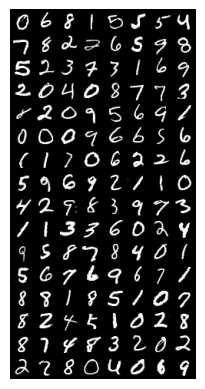

In [ ]:
def imshow(img):
  plt.axis('off')
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))#matpltlibのためCHWをHWCの配列に置換
  plt.show()

dataiter = iter(train_loader)#train_loaderからミニバッチ1回分の学習データを取得
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))

#⑦任意の画像の可視化

label: 5


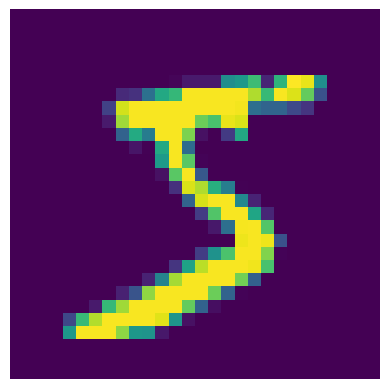

In [ ]:
num = 0#1番目のデータ
item = train_loader.dataset.data[num]
print('label:', train_loader.dataset.targets[num].numpy())
imshow(item.unsqueeze(0))

#⑧ロギング機能の実装

In [ ]:
#学習データの推論結果のロギング
class Logger():
  def __init__(self,print_iteration, train_samples, batch_size):
    self.print_iteration = print_iteration
    self.iterations = math.ceil(train_samples / batch_size)#学習にかかるループ回数
    self.log = {'loss': [],'acc': [], 'epochs':[]}
  def clear_run(self):
    self.run_loss = 0.0
    self.run_acc = 0.0
    self.run_count = 0
    self.s_time = time.time()
  def logging(self, outputs, loss, labels, epoch, i):
    b_size = outputs.size(0)
    self.run_loss += loss.item()
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum()
    accuracy = 100 * correct / b_size
    self.run_acc += accuracy.item()
    self.run_count += 1
    if i % self.print_iteration == 0 or i == self.iterations:
      e_time = (time.time() - self.s_time) / self.run_count
      progress = round(epoch + i / self.iterations, 2)
      self.log['loss'].append(self.run_loss / self.run_count)
      self.log['acc'].append(self.run_acc / self.run_count)
      self.log['epochs'].append(progress)
      print('[%5d, %9d] loss:%.3f, accuracy:%.2f%%, speed:%.3fs/iter' % (epoch, i, self.log['loss'][-1], self.log['acc'][-1], e_time))
      self.clear_run()
  def save(self, path):
    dict_ = dict(epochs = self.log['epochs'], loss = self.log['loss'],accuracy = self.log['acc'])
    df = pd.DataFrame(dict_)
    df.to_csv(path)

#テストデータの推論結果のロギング
class Evaluator():
  def __init__(self, dataloader, criterion, device):
    self.log = {'loss': [],'acc': [], 'epochs':[]}
    self.loader = dataloader
    self.device = device
    self.n_iters = len(self.loader)
    self.criterion = criterion
  def evaluation(self, model, epoch):
    model.eval()
    correct = 0
    val_loss = 0.0
    val_accuracy = 0.0
    test_samples = 0
    eval_start = time.time()
    for images, labels in self.loader:
      images = images.to(self.device)
      labels = labels.to(self.device)
      b_size = images.size(0)
      test_samples += b_size
      with torch.no_grad():
        outputs = model(images)
      loss = self.criterion(outputs, labels)
      val_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      correct += (predicted == labels).sum().item()
    eval_time = (time.time() - eval_start) / self.n_iters
    val_accuracy = 100 * correct / test_samples
    self.log['loss'].append(val_loss / self.n_iters)
    self.log['acc'].append(val_accuracy)
    self.log['epochs'].append(epoch)
    print('[%5d]test loss: %.3f, accuracy: %.2f%%, speed:%.3fs/iter' % (epoch, self.log['loss'][-1], self.log['acc'][-1], eval_time))
  def save(self, path):
    dict_ = dict(epochs = self.log['epochs'], loss = self.log['loss'],accuracy = self.log['acc'])
    df = pd.DataFrame(dict_)
    df.to_csv(path)

#⑨学習モデルの定義

In [ ]:
class MyModel(nn.Module):
    def __init__(self, units):
        super(MyModel, self).__init__()
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(units[0], units[1])
        self.fc2 = nn.Linear(units[1], units[2])
        self.fc3 = nn.Linear(units[2], units[3])
        self.relu = nn.ReLU()
    def forward(self, x):
        h = self.flat(x)#入力データの平坦化
        h = self.relu(self.fc1(h))#全結合層の後ReLU関数により活性化
        h = self.relu(self.fc2(h))#全結合層の後ReLU関数により活性化
        y = self.fc3(h)#全結合層
        return y
    def predict(self, x):
        y = self.forward(x)
        return F.softmax(y, dim=1)#softmax関数を通して推論結果を出力

#⑩モデルのインスタンス生成等

In [ ]:
learning_rate = 0.01#学習率
init_seed(seed)#seed固定
input_size = image_size*image_size
units = [input_size, 64, 32, 10]#層の構成　入力層→全結合層→全結合層→出力
device = 'cude' if torch.cuda.is_available() else 'cpu'
print('use device:', device)
model = MyModel(units).to(device)
summary(model, (input_size,),device=device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)#最適化手法にSGDを利用
print('optimizer',optimizer)

use device: cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 64]          50,240
              ReLU-3                   [-1, 64]               0
            Linear-4                   [-1, 32]           2,080
              ReLU-5                   [-1, 32]               0
            Linear-6                   [-1, 10]             330
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.20
Estimated Total Size (MB): 0.21
----------------------------------------------------------------
optimizer SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum

#⑪モデルの学習

In [ ]:
n_epoch=10#エポック数
print_iteration=100#任意の値　学習時のロギング間隔
logger=Logger(print_iteration,train_samples,batch_size)
eval=Evaluator(test_loader,criterion,device)
start=time.time()
for epoch in tqdm(range(n_epoch)):#エポック数だけ学習を行う
  eval.evaluation(model,epoch)
  model.train()
  logger.clear_run()
  print_time=time.time()
  for i,(images,labels) in enumerate(train_loader,0):
    images=images.to(device)
    labels=labels.to(device)
    outputs=model(images)
    optimizer.zero_grad()
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    logger.logging(outputs,loss,labels,epoch,i+1)
eval.evaluation(model,n_epoch)
elapsed_time=time.time()-start
print('training total',elapsed_time,'sec.')#合計の処理時間

  0%|          | 0/10 [00:00<?, ?it/s]

[    0]test loss: 2.305, accuracy: 13.08%, speed:0.026s/iter
[    0,       100] loss:2.292, accuracy:15.52%, speed:0.027s/iter
[    0,       200] loss:2.254, accuracy:20.62%, speed:0.018s/iter
[    0,       300] loss:2.194, accuracy:28.64%, speed:0.017s/iter
[    0,       400] loss:2.093, accuracy:37.23%, speed:0.017s/iter
[    0,       469] loss:1.969, accuracy:40.89%, speed:0.016s/iter
[    1]test loss: 1.907, accuracy: 40.73%, speed:0.017s/iter
[    1,       100] loss:1.821, accuracy:44.42%, speed:0.018s/iter
[    1,       200] loss:1.607, accuracy:57.03%, speed:0.022s/iter
[    1,       300] loss:1.358, accuracy:67.45%, speed:0.027s/iter
[    1,       400] loss:1.116, accuracy:72.15%, speed:0.027s/iter
[    1,       469] loss:0.972, accuracy:75.12%, speed:0.017s/iter
[    2]test loss: 0.901, accuracy: 77.17%, speed:0.017s/iter
[    2,       100] loss:0.870, accuracy:76.86%, speed:0.018s/iter
[    2,       200] loss:0.786, accuracy:78.45%, speed:0.017s/iter
[    2,       300] loss:0

#⑫モデルの保存



In [ ]:
base_fol = '/gdrive/MyDrive/実験' #MyDrive内のモデルを保存したいところにパスを指定する
os.makedirs(base_fol,exist_ok = True)
torch.save(model.state_dict(),os.path.join(base_fol,'mnist.pth'))#モデル保存
logger.save(os.path.join(base_fol,'train_loss_acc.csv'))#学習のロギング
eval.save(os.path.join(base_fol,'test_loss_acc.csv'))#推論のロギング
with open( os.path.join(base_fol,'architecture.txt'),mode = "w") as f:
  f.write('model\n')
  f.write(str(model))
  f.write('optimizer\n')
  f.write(str(optimizer))

#⑬学習結果の可視化

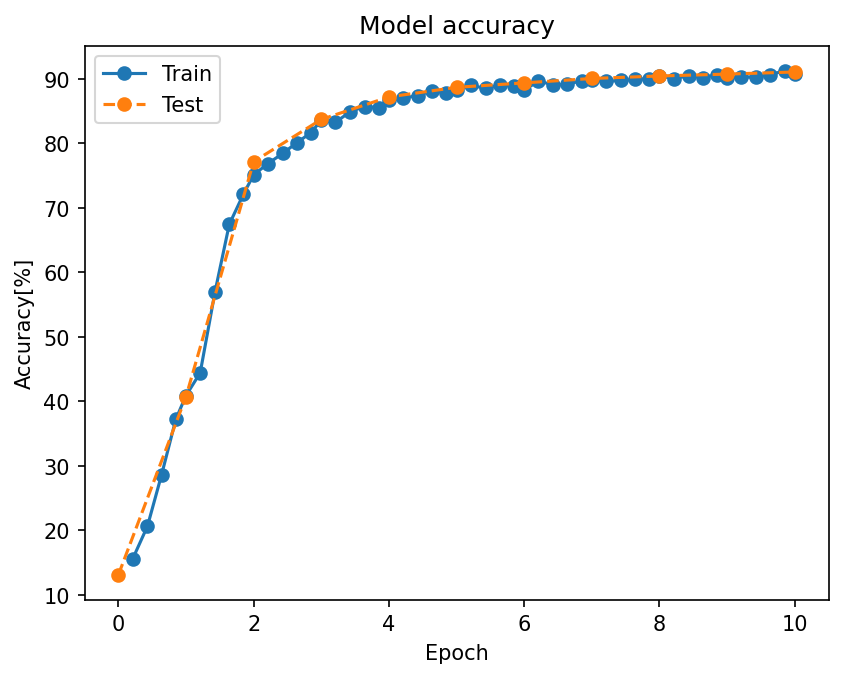

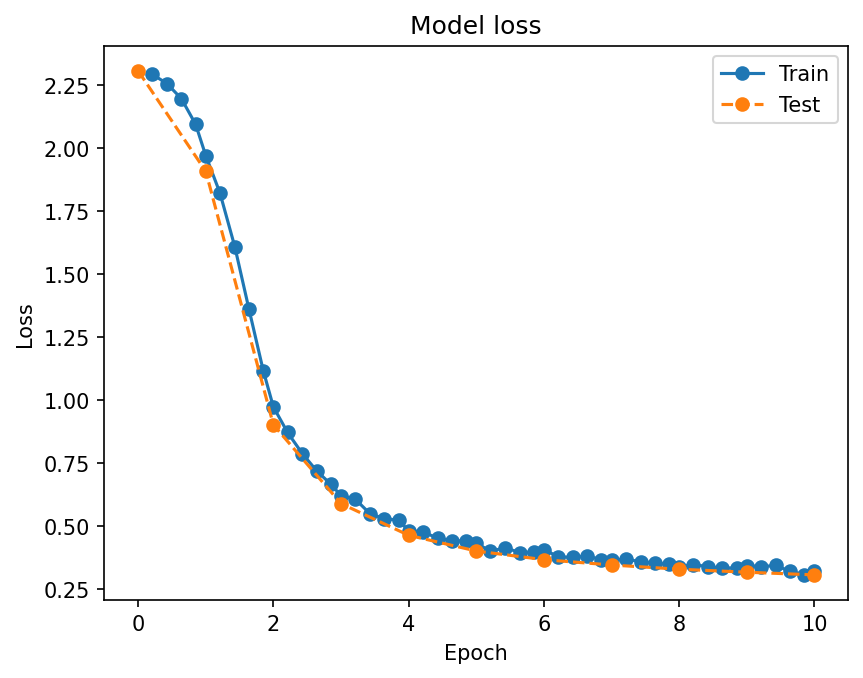

In [ ]:
# 13
mpl.rcParams['figure.dpi'] = 150
#グラフのプロット
plt.plot(logger.log['epochs'], logger.log['acc'], marker="o")
plt.plot(eval.log['epochs'], eval.log['acc'], linestyle="--", marker="o")
plt.title('Model accuracy')
plt.ylabel('Accuracy[%]')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()

plt.plot(logger.log['epochs'], logger.log['loss'], marker="o")
plt.plot(eval.log['epochs'], eval.log['loss'], linestyle="--", marker="o")
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()

#⑭推論

In [ ]:
# 14
num = 1
item = train_loader.dataset.data[num].unsqueeze(0)#バッチサイズ1として、学習用データセットからnum+1番目の画像を取り出す
print('label:', train_loader.dataset.targets[num].numpy())
model.eval()
#推論
with torch.no_grad():
  yhat = model.predict(item / 255.)
print('predicts:\n', yhat)

label: 0
predicts:
 tensor([[9.9708e-01, 1.3295e-09, 7.8507e-05, 4.1560e-05, 9.3431e-08, 2.7746e-03,
         4.2943e-06, 9.4721e-07, 1.2557e-05, 7.3196e-06]])


#⑮モデルの読み込みと推論

In [ ]:
#保存したモデルのロード
load_model = MyModel(units)
load_model.load_state_dict(
    torch.load(
        os.path.join(base_fol, 'mnist.pth')
    )
)

num = 1
item = train_loader.dataset.data[num].unsqueeze(0)
print('label:', train_loader.dataset.targets[num].numpy())
model.eval()
with torch.no_grad():
  yhat = model.predict(item / 255.)
print('predicts:\n', yhat)

label: 0
predicts:
 tensor([[9.9708e-01, 1.3295e-09, 7.8507e-05, 4.1560e-05, 9.3431e-08, 2.7746e-03,
         4.2943e-06, 9.4721e-07, 1.2557e-05, 7.3196e-06]])


# ⑯　学生番号での推論

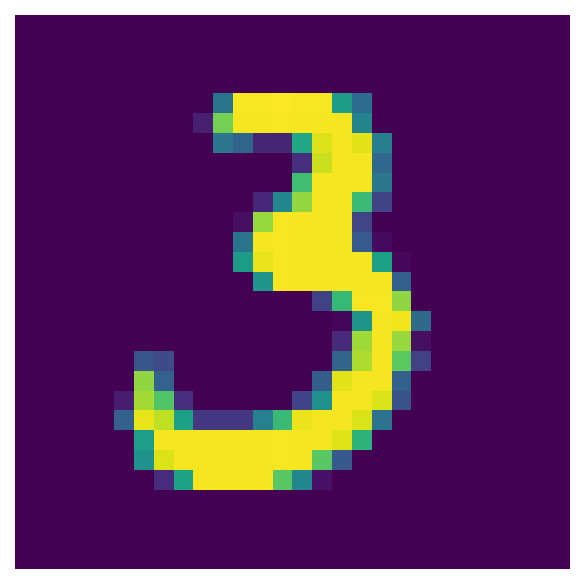

label: 3
predicts:
 tensor([[9.1499e-05, 4.4562e-05, 6.1672e-04, 9.9765e-01, 2.7544e-09, 1.4446e-03,
         1.8484e-07, 3.3127e-05, 1.1055e-04, 9.5496e-06]])


In [ ]:
num = 4053
item = train_loader.dataset.data[num]
imshow(item.unsqueeze(0))
item = train_loader.dataset.data[num].unsqueeze(0)
print('label:', train_loader.dataset.targets[num].numpy())
model.eval()
with torch.no_grad():
  yhat = model.predict(item / 255.)
print('predicts:\n', yhat)

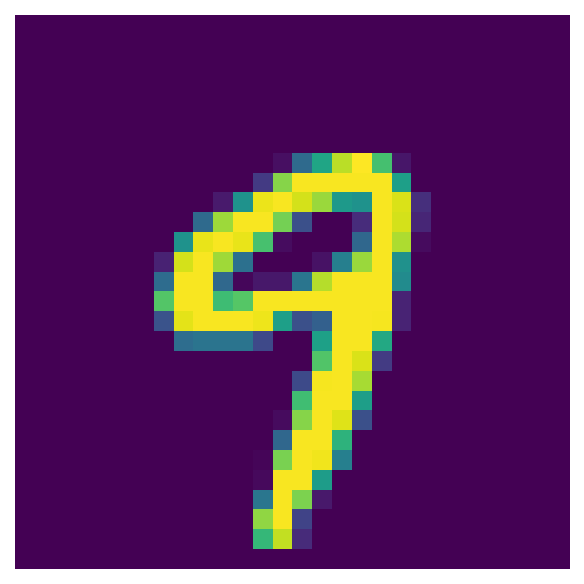

label: 9
predicts:
 tensor([[5.2691e-05, 7.8243e-07, 1.0396e-05, 3.4928e-04, 8.4129e-02, 1.7537e-03,
         9.3459e-06, 1.2046e-02, 1.2320e-03, 9.0042e-01]])


In [ ]:
num = 4095
item = train_loader.dataset.data[num]
imshow(item.unsqueeze(0))
print('label:', train_loader.dataset.targets[num].numpy())
item = train_loader.dataset.data[num].unsqueeze(0)
model.eval()
with torch.no_grad():
  yhat = model.predict(item / 255.)
print('predicts:\n', yhat)

label: 6


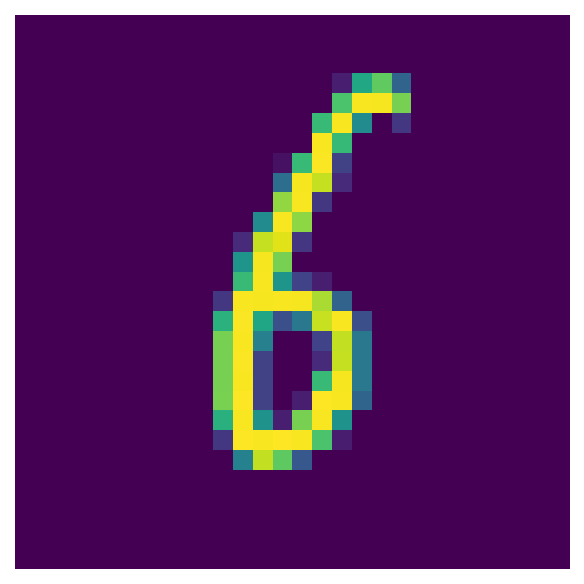

label: 6
predicts:
 tensor([[3.3547e-04, 3.1478e-04, 6.3024e-03, 2.4786e-04, 8.6390e-04, 1.2081e-02,
         9.7378e-01, 3.0989e-06, 5.6707e-03, 4.0566e-04]])


In [ ]:
num = 4090
item = train_loader.dataset.data[num]
print('label:', train_loader.dataset.targets[num].numpy())
imshow(item.unsqueeze(0))

#num = 1
item = train_loader.dataset.data[num].unsqueeze(0)
print('label:', train_loader.dataset.targets[num].numpy())
model.eval()
with torch.no_grad():
  yhat = model.predict(item / 255.)
print('predicts:\n', yhat)

label: 0


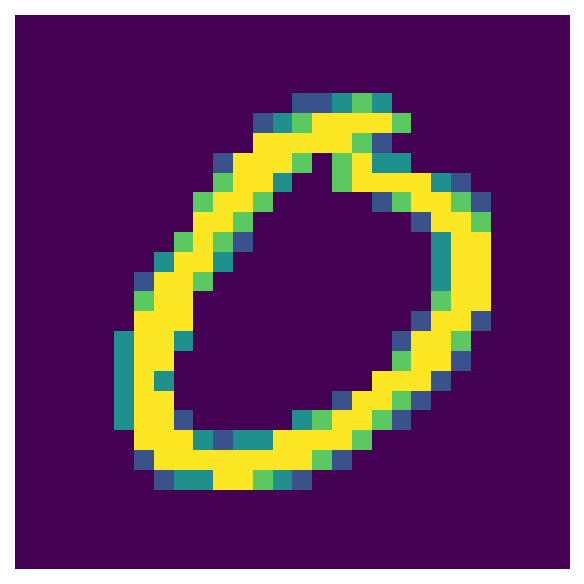

label: 0
predicts:
 tensor([[9.9813e-01, 9.8300e-11, 3.0631e-05, 1.1063e-05, 8.7810e-09, 1.8229e-03,
         1.3271e-06, 3.3179e-09, 5.7283e-06, 9.1915e-08]])


In [ ]:
num = 5622
item = train_loader.dataset.data[num]
print('label:', train_loader.dataset.targets[num].numpy())
imshow(item.unsqueeze(0))

#num = 1
item = train_loader.dataset.data[num].unsqueeze(0)
print('label:', train_loader.dataset.targets[num].numpy())
model.eval()
with torch.no_grad():
  yhat = model.predict(item / 255.)
print('predicts:\n', yhat)